In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
df = pd.read_csv('/content/drive/MyDrive/Deep Learning Projects/CNN-LSTM-TimeSeries/atmospheric_pressure_50_cities.csv')
df.head()

,City,P_Day_1,P_Day_2,P_Day_3,P_Day_4,P_Day_5,P_Day_6,P_Day_7,P_Day_8,P_Day_9,...,P_Day_22,P_Day_23,P_Day_24,P_Day_25,P_Day_26,P_Day_27,P_Day_28,P_Day_29,P_Day_30,Heavy_Rain_Next_Day
0,City_1,1018.0,1018.0,1017.6,1017.5,1017.6,1017.4,1017.1,1017.1,1016.8,...,1015.0,1015.0,1015.0,1014.7,1014.8,1014.5,1014.5,1014.3,1014.5,0
1,City_2,1016.7,1016.1,1015.9,1015.3,1015.0,1014.9,1014.6,1014.2,1013.8,...,1009.3,1008.7,1008.5,1008.2,1007.9,1007.4,1007.1,1006.6,1006.2,1
2,City_3,1019.6,1019.5,1019.1,1018.7,1018.6,1018.5,1018.0,1017.9,1017.0,...,1013.8,1013.4,1013.3,1012.9,1012.8,1012.2,1012.0,1011.7,1011.3,0
3,City_4,1020.1,1019.9,1019.5,1019.5,1019.4,1019.1,1019.0,1019.0,1019.0,...,1016.6,1016.5,1016.1,1016.2,1015.6,1015.8,1015.8,1015.2,1015.1,0
4,City_5,1016.0,1015.9,1015.4,1015.4,1014.8,1014.9,1014.3,1014.0,1013.9,...,1009.9,1009.4,1009.2,1008.9,1008.5,1008.6,1008.1,1007.5,1007.5,1


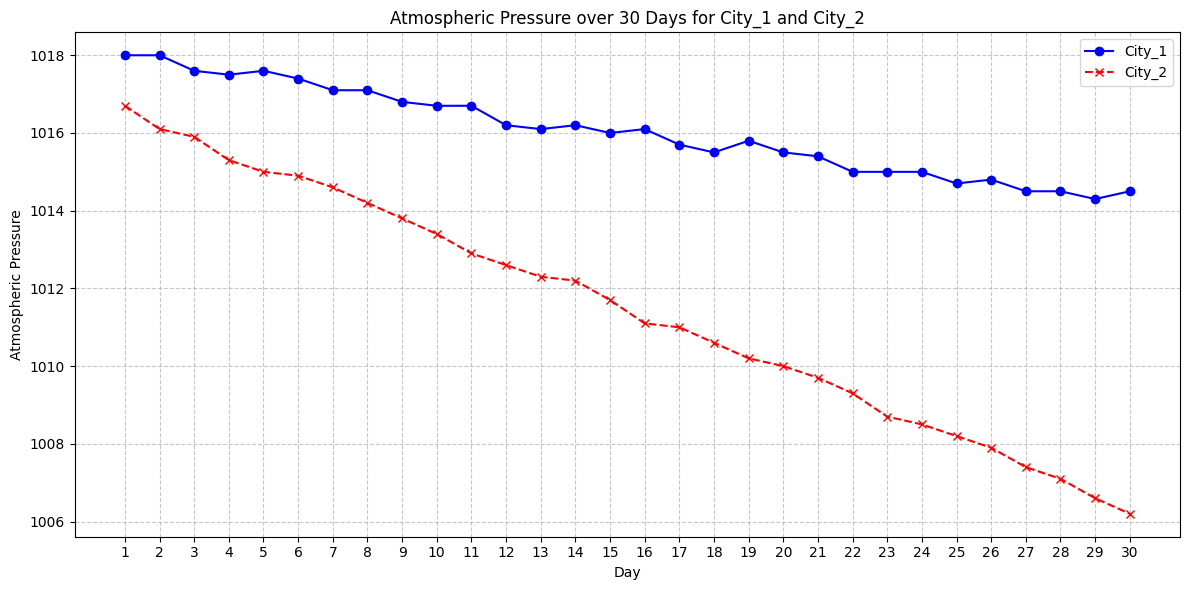

In [3]:
import matplotlib.pyplot as plt

# Extract pressure columns (P_Day_1 to P_Day_30)
pressure_columns = [f'P_Day_{i}' for i in range(1, 31)]

# Extract data for City_1 (row 0) and City_2 (row 1)
city_1_pressure = df.loc[0, pressure_columns]
city_2_pressure = df.loc[1, pressure_columns]

# Create a day index for the x-axis
days = range(1, 31)

# Plot the data
plt.figure(figsize=(12, 6))
plt.plot(days, city_1_pressure, label='City_1', color='blue', marker='o', linestyle='-')
plt.plot(days, city_2_pressure, label='City_2', color='red', marker='x', linestyle='--')

plt.title('Atmospheric Pressure over 30 Days for City_1 and City_2')
plt.xlabel('Day')
plt.ylabel('Atmospheric Pressure')
plt.xticks(days) # Ensure all days are marked on the x-axis
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
# Function to apply Min-Max scaling to a Series
def min_max_scale(series):
    min_val = series.min()
    max_val = series.max()
    if (max_val - min_val) == 0: # Avoid division by zero if all values are the same
        return series - min_val
    return (series - min_val) / (max_val - min_val)

# Apply scaling to city_1_pressure and city_2_pressure
scaled_city_1_pressure = min_max_scale(city_1_pressure)
scaled_city_2_pressure = min_max_scale(city_2_pressure)

# Display a snippet of the scaled data to confirm
print("Scaled City 1 Pressure (first 5 days):")
print(scaled_city_1_pressure.head())
print("\nScaled City 2 Pressure (first 5 days):")
print(scaled_city_2_pressure.head())

Scaled City 1 Pressure (first 5 days):
P_Day_1         1.0
P_Day_2         1.0
P_Day_3    0.891892
P_Day_4    0.864865
P_Day_5    0.891892
Name: 0, dtype: object

Scaled City 2 Pressure (first 5 days):
P_Day_1         1.0
P_Day_2    0.942857
P_Day_3     0.92381
P_Day_4    0.866667
P_Day_5    0.838095
Name: 1, dtype: object


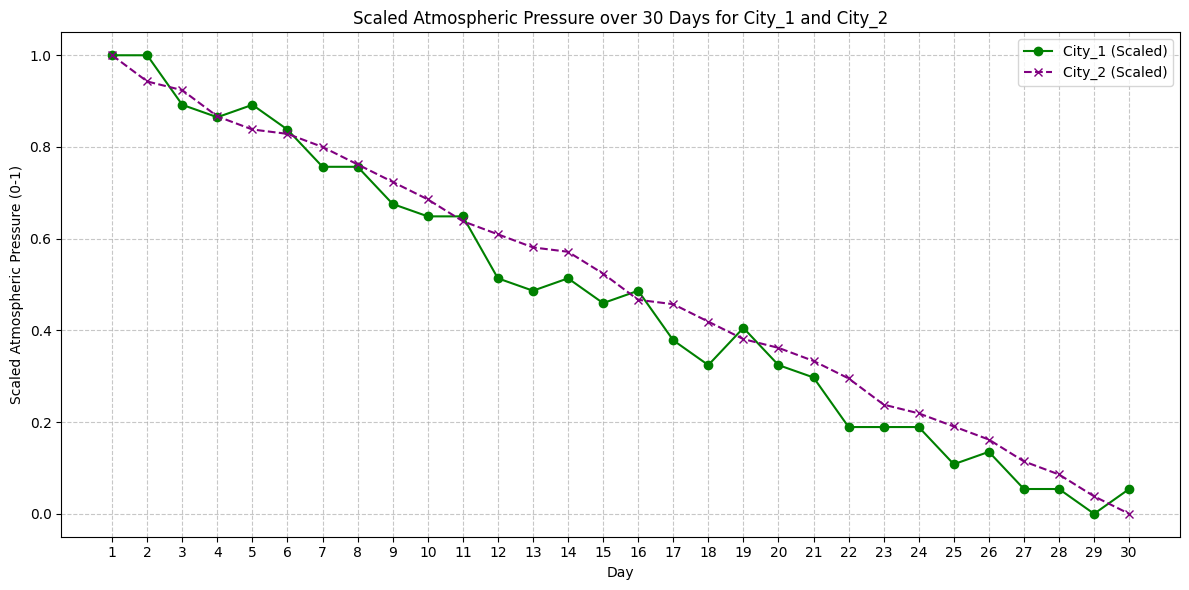

In [5]:
import matplotlib.pyplot as plt

# Create a day index for the x-axis
days = range(1, 31)

# Plot the scaled data
plt.figure(figsize=(12, 6))
plt.plot(days, scaled_city_1_pressure, label='City_1 (Scaled)', color='green', marker='o', linestyle='-')
plt.plot(days, scaled_city_2_pressure, label='City_2 (Scaled)', color='purple', marker='x', linestyle='--')

plt.title('Scaled Atmospheric Pressure over 30 Days for City_1 and City_2')
plt.xlabel('Day')
plt.ylabel('Scaled Atmospheric Pressure (0-1)')
plt.xticks(days) # Ensure all days are marked on the x-axis
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()

In [6]:
df = df.drop(columns=['City'])

In [7]:
df

,P_Day_1,P_Day_2,P_Day_3,P_Day_4,P_Day_5,P_Day_6,P_Day_7,P_Day_8,P_Day_9,P_Day_10,...,P_Day_22,P_Day_23,P_Day_24,P_Day_25,P_Day_26,P_Day_27,P_Day_28,P_Day_29,P_Day_30,Heavy_Rain_Next_Day
0,1018.0,1018.0,1017.6,1017.5,1017.6,1017.4,1017.1,1017.1,1016.8,1016.7,...,1015.0,1015.0,1015.0,1014.7,1014.8,1014.5,1014.5,1014.3,1014.5,0
1,1016.7,1016.1,1015.9,1015.3,1015.0,1014.9,1014.6,1014.2,1013.8,1013.4,...,1009.3,1008.7,1008.5,1008.2,1007.9,1007.4,1007.1,1006.6,1006.2,1
2,1019.6,1019.5,1019.1,1018.7,1018.6,1018.5,1018.0,1017.9,1017.0,1017.2,...,1013.8,1013.4,1013.3,1012.9,1012.8,1012.2,1012.0,1011.7,1011.3,0
3,1020.1,1019.9,1019.5,1019.5,1019.4,1019.1,1019.0,1019.0,1019.0,1018.6,...,1016.6,1016.5,1016.1,1016.2,1015.6,1015.8,1015.8,1015.2,1015.1,0
4,1016.0,1015.9,1015.4,1015.4,1014.8,1014.9,1014.3,1014.0,1013.9,1013.3,...,1009.9,1009.4,1009.2,1008.9,1008.5,1008.6,1008.1,1007.5,1007.5,1
5,1019.7,1019.0,1018.7,1018.2,1017.8,1017.4,1016.6,1016.1,1015.6,1015.1,...,1009.5,1008.9,1008.6,1008.1,1007.5,1006.9,1006.3,1006.0,1005.7,1
6,1016.9,1016.6,1016.1,1015.9,1015.6,1015.1,1015.0,1014.7,1014.4,1014.1,...,1010.2,1009.7,1009.4,1009.1,1008.8,1008.8,1007.9,1007.9,1007.3,1
7,1016.1,1015.7,1015.0,1014.2,1013.7,1013.3,1012.6,1012.1,1011.5,1010.8,...,1003.9,1003.3,1002.7,1002.5,1001.7,1000.8,1000.6,1000.2,999.4,1
8,1018.3,1017.5,1017.2,1016.8,1016.1,1015.7,1014.8,1014.6,1014.3,1013.6,...,1008.0,1007.6,1007.1,1006.7,1006.3,1006.0,1005.1,1005.1,1004.0,1
9,1020.7,1020.2,1019.9,1019.4,1019.0,1018.8,1018.3,1017.8,1017.6,1017.1,...,1012.1,1011.7,1011.5,1011.1,1010.7,1010.3,1009.7,1009.4,1008.9,1


In [8]:
X = np.array(df.drop(columns='Heavy_Rain_Next_Day'))
Y = np.array(df['Heavy_Rain_Next_Day'])

In [9]:
X.shape

(50, 30)

In [10]:
Y.shape

(50,)

In [11]:
X = X.reshape([50,30,1])

In [12]:
X.shape

(50, 30, 1)

In [15]:
# Define the Min-Max scaling function for a 1D array
def min_max_scale_array(arr):
    min_val = np.min(arr)
    max_val = np.max(arr)
    if (max_val - min_val) == 0:
        return arr - min_val  # If all values are the same, return an array of zeros
    return (arr - min_val) / (max_val - min_val)

# Create a new array to store the scaled data
X_scaled = np.zeros_like(X, dtype=float)

# Iterate through each row (city) and apply the scaling
for i in range(X.shape[0]):
    # X[i, :, 0] extracts the 1D pressure series for the i-th city
    scaled_row = min_max_scale_array(X[i, :, 0])
    # Assign the scaled 1D array back to the 3D X_scaled array
    X_scaled[i, :, 0] = scaled_row

X = X_scaled

print("Shape of X after row-wise scaling:", X.shape)
print("\nFirst row of X after scaling (first 5 days):")
print(X[0, :5, 0])
print("\nSecond row of X after scaling (first 5 days):")
print(X[1, :5, 0])

Shape of X after row-wise scaling: (50, 30, 1)

First row of X after scaling (first 5 days):
[1.         1.         0.89189189 0.86486486 0.89189189]

Second row of X after scaling (first 5 days):
[1.         0.94285714 0.92380952 0.86666667 0.83809524]


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [17]:
X.max()

np.float64(1.0)

In [18]:
X.min()

np.float64(0.0)

In [28]:
from keras.models import Sequential
from keras.layers import (
    Conv1D, LSTM, Dense, Dropout,
    BatchNormalization, Bidirectional, MaxPooling1D
)
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.optimizers import Adam

model = Sequential()

# ----- CNN FEATURE EXTRACTOR -----
model.add(Conv1D(64, 3, activation='relu', input_shape=(30, 1)))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

model.add(Conv1D(128, 3, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(pool_size=2))

# ----- TEMPORAL MODELING -----
model.add(Bidirectional(LSTM(64, return_sequences=False)))

# ----- REGULARIZATION -----
model.add(Dropout(0.4))

# ----- DENSE HEAD -----
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))
model.add(Dense(1, activation='sigmoid'))

# ----- COMPILE -----
model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 28, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 28, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 14, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 12, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 12, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 6, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,865 (519.00 KB)

 Trainable params: 132,481 (517.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [29]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-5
)

In [30]:
model.fit(
    X_train, Y_train,
    validation_data=(X_test, Y_test),
    epochs=50,
    batch_size=8,
    callbacks=[early_stop]
)

Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 162ms/step - accuracy: 0.3344 - loss: 0.7703 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.8708 - loss: 0.5825 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.6795 - loss: 0.5937 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7365 - loss: 0.5326 - val_accuracy: 0.5000 - val_loss: 0.6932
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7149 - loss: 0.5525 - val_accuracy: 0.5000 - val_loss: 0.6931
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.8628 - loss: 0.4650 - val_accuracy: 0.5000 - val_loss: 0.6926
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7892 - loss: 0.4562 - val_accuracy: 0.5000 - val_loss: 0.6924
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8819 - loss: 0.3539 - val_accuracy: 0.5000 - val_loss: 0.6918

<Axes: >

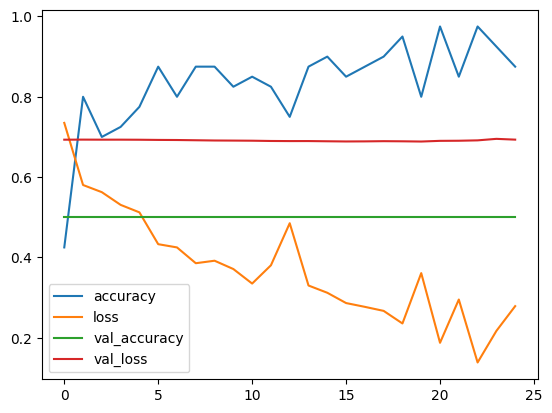

In [31]:
loss_df = pd.DataFrame(model.history.history)
loss_df.plot()